# Heterogeneous mini-batching: from typed queries to seed predictions

Tier C synthetic data · native CPU NeighborLoader; all 96 audits and nine fits. No repository imports, hidden trainer or dataset download. PENDING_WRITTEN_DEFENSE.

Install the environment described in [the reproduction contract](https://avistian.github.io/relational/labs/l098-reproduction.md). Live Colab is NOT_CHECKED; the compiled sampler is required.

In [1]:
# @colab-bootstrap
# This notebook is self-contained; the native extension must match your torch build.
# Use the exact environment instructions in l098-reproduction.md before this cell.
# No Python fallback is substituted if native sampling is unavailable.
import importlib.metadata as metadata
import torch_geometric.typing as pyg_typing
print({k:metadata.version(k) for k in ['torch','torch-geometric','pyg-lib']})
assert pyg_typing.WITH_PYG_LIB, 'Install the pinned compatible pyg-lib build and restart the kernel.'


/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'torch': '2.13.0+cpu', 'torch-geometric': '2.8.0.post1', 'pyg-lib': '0.10.0'}


<div class="package-links"><strong>Your tangible win:</strong> train a three-type GNN with a real heterogeneous NeighborLoader, then prove which parts of its computation a mini-batch preserves.<br><a href="https://avistian.github.io/relational/labs/0098-hetero-mini-batching.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/solutions/0098-hetero-mini-batching.ipynb">Executed solution</a> · <a href="https://avistian.github.io/relational/labs/html/0098-hetero-mini-batching.html">Read the solution</a> · <a href="https://avistian.github.io/relational/labs/l098-reproduction.md">Full reproduction contract</a></div>



## 1 · Retrieve before reading — 5 minutes

Recall typed identity and temporal availability before reading.

Write answers before opening the feedback. (1) In L096, does local row 0 identify an entity without a table type? (2) For the edge orders → customer, whose representation changes after one message-passing layer? (3) Does L097's negative sampler choose the neighbors needed to compute an embedding? (4) Why should training exclude a future order even if its customer ID is already known?

<details><summary>Check after committing your answers</summary><p>Identity is (table type, row ID). Source orders send messages to destination customers. Negative sampling chooses contrasting targets; neighborhood sampling chooses encoder inputs. A known entity can still acquire information that was unavailable at prediction time. Filtering training labels alone does not remove that information.</p></details>

[Lesson 96](https://avistian.github.io/relational/lessons/0096-multi-relational-data.html) gave every row and FK a typed identity. [Lesson 97](https://avistian.github.io/relational/lessons/0097-negative-sampling.html) separated training targets from evaluation candidates. Neither tells us how to compute an embedding when the graph is too large for one forward pass. This lesson supplies that missing execution mechanism. Recall the expanding neighborhoods of [GraphSAGE](https://avistian.github.io/relational/lessons/0083-graphsage.html) and the partition approach of [Cluster-GCN](https://avistian.github.io/relational/lessons/0089-sampling-at-scale.html): here the unit of work is a set of typed seed nodes and their incoming dependencies.

**Route:** 25 minutes for sections 2–6; a separate lab session for implementation, execution and written defense. The mission connection is direct: RelBench entity models use a heterogeneous neighbor loader to turn database graphs into trainable batches. Our fixture shares that shape, but is not a RelBench dataset or benchmark reproduction. [Inspect the pinned RelBench entity example](https://github.com/stanford-star/relbench/blob/584a03d518b2b655580ea8e1cfbbb26bec0a2841/examples/gnn_entity.py).

<!-- depth-walkthrough:start -->


## The big picture · a batch is a query-specific computation graph

<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · 098 / DEPENDENCIES AND TARGETS</p><p><strong>Bring forward:</strong> L096 made table-local identity explicit; L083 expanded graph dependencies from roots. <strong>Follow:</strong> seed query → eligible typed neighbors → local maps → shared layers → seed outputs. <strong>Carry forward:</strong> L100 tests these contracts on a real graph before interpreting a model comparison.</p><p><a href="https://avistian.github.io/relational/lessons/0096-multi-relational-data.html">L096: database keys</a> · <a href="https://avistian.github.io/relational/lessons/0083-graphsage.html">L083: outward sampling</a> · <a href="https://avistian.github.io/relational/lessons/0100-heterogeneous-gnn-checkpoint.html">L100: integrated audit</a> · <a href="https://avistian.github.io/relational/reference/0091-0100-model-map.html">Sequence map</a></p></div>

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Scrollable architecture: Typed mini-batching · expand out, compute inward">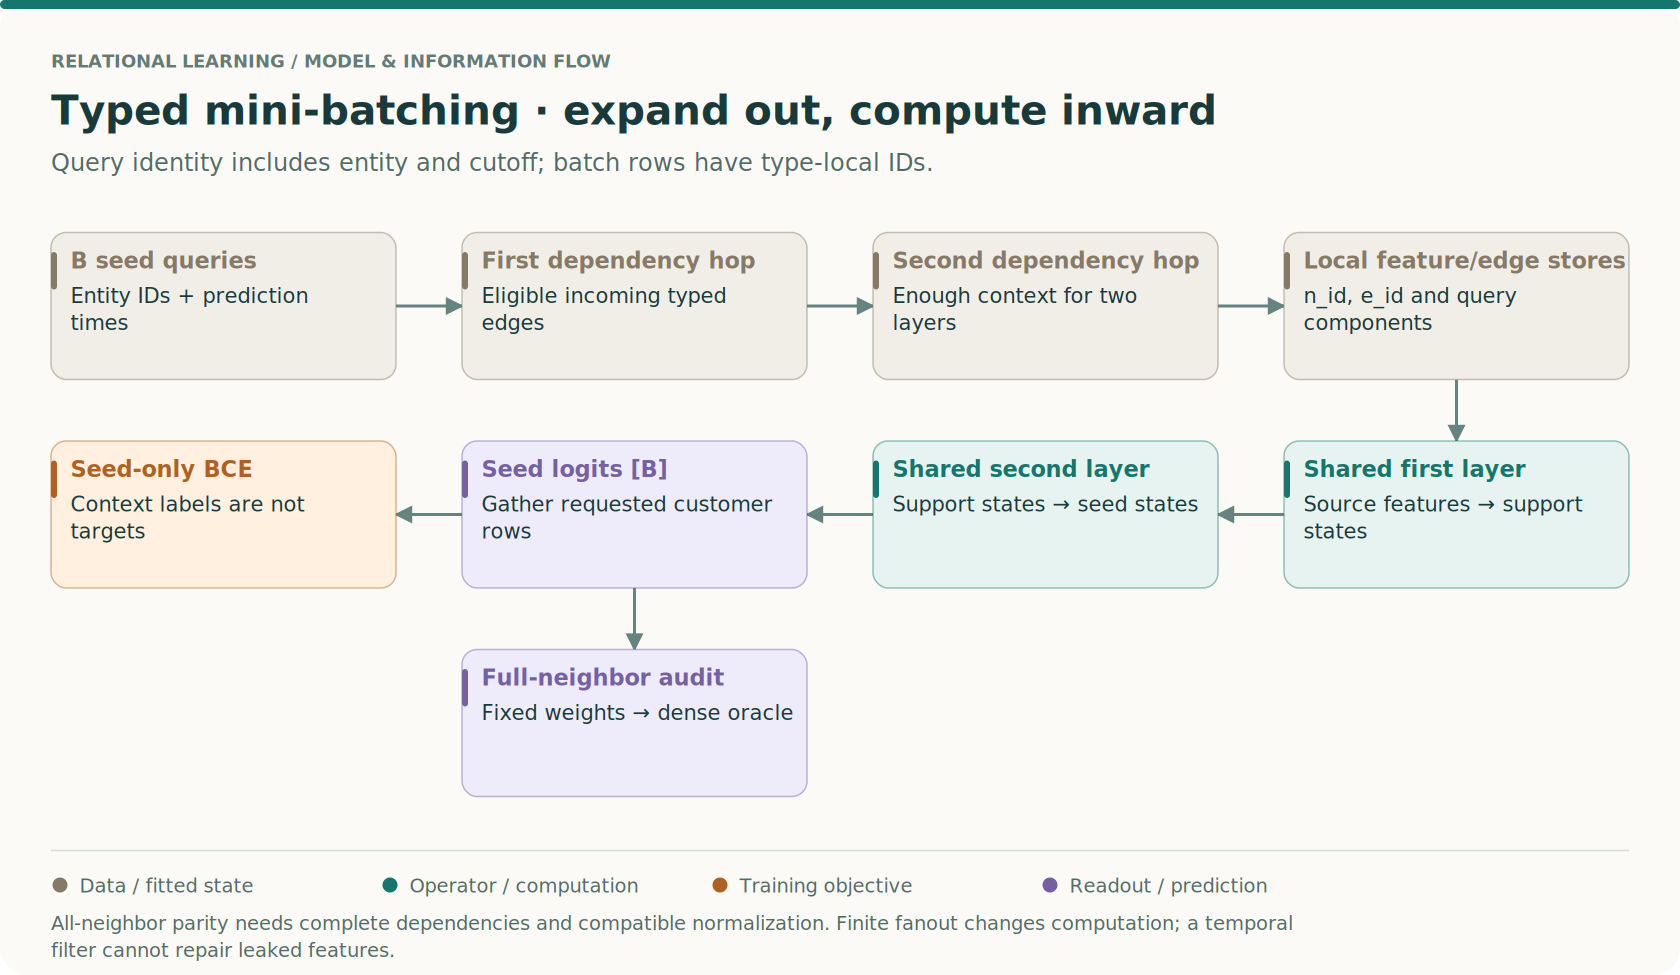</div><figcaption>Query identity includes entity and cutoff; batch rows have type-local IDs. All-neighbor parity needs complete dependencies and compatible normalization. Finite fanout changes computation; a temporal filter cannot repair leaked features.</figcaption></figure>

### Draw the arrows in both directions

To predict for a customer with a two-layer encoder, first discover the customer's incoming neighbors, then the inputs those neighbors need. Dependency discovery moves outward from the seed. Computation moves inward: original features form first-layer support states, which form the seed's second-layer state. Reversing the sampling list is not enough; the actual edge direction and layer dependencies must agree.

Read the [pinned NeighborLoader source](https://pytorch-geometric.readthedocs.io/en/2.6.1/_modules/torch_geometric/loader/neighbor_loader.html) for `input_nodes`, typed fanouts, seed prefix and `n_id`. These are data-routing contracts. They do not select a neural architecture or automatically enforce your task's temporal boundary.

### Count a dependency tree before trusting a batch size

In a single-relation example with B roots and fanouts f₁/f₂, the expanded occurrences are bounded by `B + B f₁ + B f₁ f₂` before deduplication. With B=4, f₁=3, f₂=2, that is 40 occurrences. It is not necessarily 40 unique nodes. Shared neighbors can reduce the count; disjoint temporal queries can retain multiple copies of one global entity. With several relations, each per-relation expansion contributes, so using only one relation's fanout can badly understate the workload.

This count is a planning bound, not a memory benchmark. Hidden widths, edges, attention heads, saved gradients and native sampler buffers also consume memory. The existing experiment reports batch sizes as workload evidence rather than claiming an unmeasured peak-memory reduction.

### Recover identity before recovering a label

There are now three naming systems: database primary key, full-graph type-local row, and batch-local row. The first conversion belongs to L096; the second belongs to the sampler. An edge's source index must use the source type's map, while its destination index uses the destination type's map. Valid integer ranges alone cannot catch swapping those maps.

For temporal queries, include the prediction time in the identity. Customer 10 at day 2 and customer 10 at day 5 can need different context and different target labels. One global entity ID does not identify both prediction examples. Disjoint query components can hold two copies with the same `n_id` while preserving different cutoffs. The fixture's temporal audit checks this separately from ordinary target masking.

### Derive the direct supervision boundary

Suppose a batch contains two customer seeds and three additional customer context nodes. It may compute five logits, but the declared objective averages only the first two seed losses. A context feature can receive gradient through a path into a seed prediction. Its own output logit receives no **direct** supervised gradient when it is outside the seed loss. Those statements are compatible: the graph carries useful context without treating every sampled label as a training target.

Full-neighbor equivalence needs complete receptive fields, identical weights and compatible normalization. A mean over the entire batch would change when the batch changes; node-wise operations do not introduce that particular dependency. Finite fanout is an additional approximation even when all identity and loss checks pass.

<details><summary>Predict first: do two layers always require only one sampled hop?</summary><p>No. A first-hop neighbor's first-layer state generally depends on its own neighbors. A second-hop source can therefore affect the root's second-layer output. One hop is sufficient only under an additional model-specific restriction, such as using fixed precomputed neighbor states with an explicit provenance contract.</p></details>

**Forward connection.** L099 first removes the sampler from the model comparison by using full-graph computation. L100 puts sampled training back and checks equal target exposure and paired sampled edges. Before moving on, draw one seed's complete two-layer dependency graph and mark which labels may contribute. Ask the teacher to perturb one future feature and predict whether an earlier query is allowed to change.

<!-- depth-walkthrough:end -->



## 2 · Define the query before defining the batch

Our complete generated database has **24 customers, 144 order events and 12 products**. Every customer has six orders, on days 1 through 6. An order points to its customer and product; explicit reverse stores permit information to travel back. Each type has four features. A customer's target is the sign of the average first product feature among its orders on days 1–5. This synthetic historical target makes the useful two-hop route explicit. It is not a future churn label.

| Store | Meaning | Shape before cutoff filtering |
|---|---|---|
| `customer.x` | Static customer covariates | [24, 4] |
| `orders.x`, `orders.time` | Event covariates and availability day | [144, 4], [144] |
| `product.x` | Static product covariates | [12, 4] |
| orders → customer, customer → orders | Buyer FK and reverse view | each [2, 144] |
| orders → product, product → orders | Product FK and reverse view | each [2, 144] |

For ordinary training, remove edges touching day-6 orders in **both** directions. Row IDs stay stable; inaccessible orders remain isolated. There are now 480 directed edges. Customers 0–15 are fitting seeds, 16–19 validation seeds, and 20–23 test seeds. Products are shared static context. This is a transductive feature setting: an input graph need not contain only training entities, but no held-out labels enter the fitting loss. Features are generated without using labels; the target is created afterward.

**Prediction:** how many order neighbors can customer 7 have at cutoff 5? Five. Its six-order total is not the degree the legal encoder may use. Merely calling a sampler on the unfiltered graph would not enforce this boundary.



## 3 · Model architecture — expand backward, compute forward

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">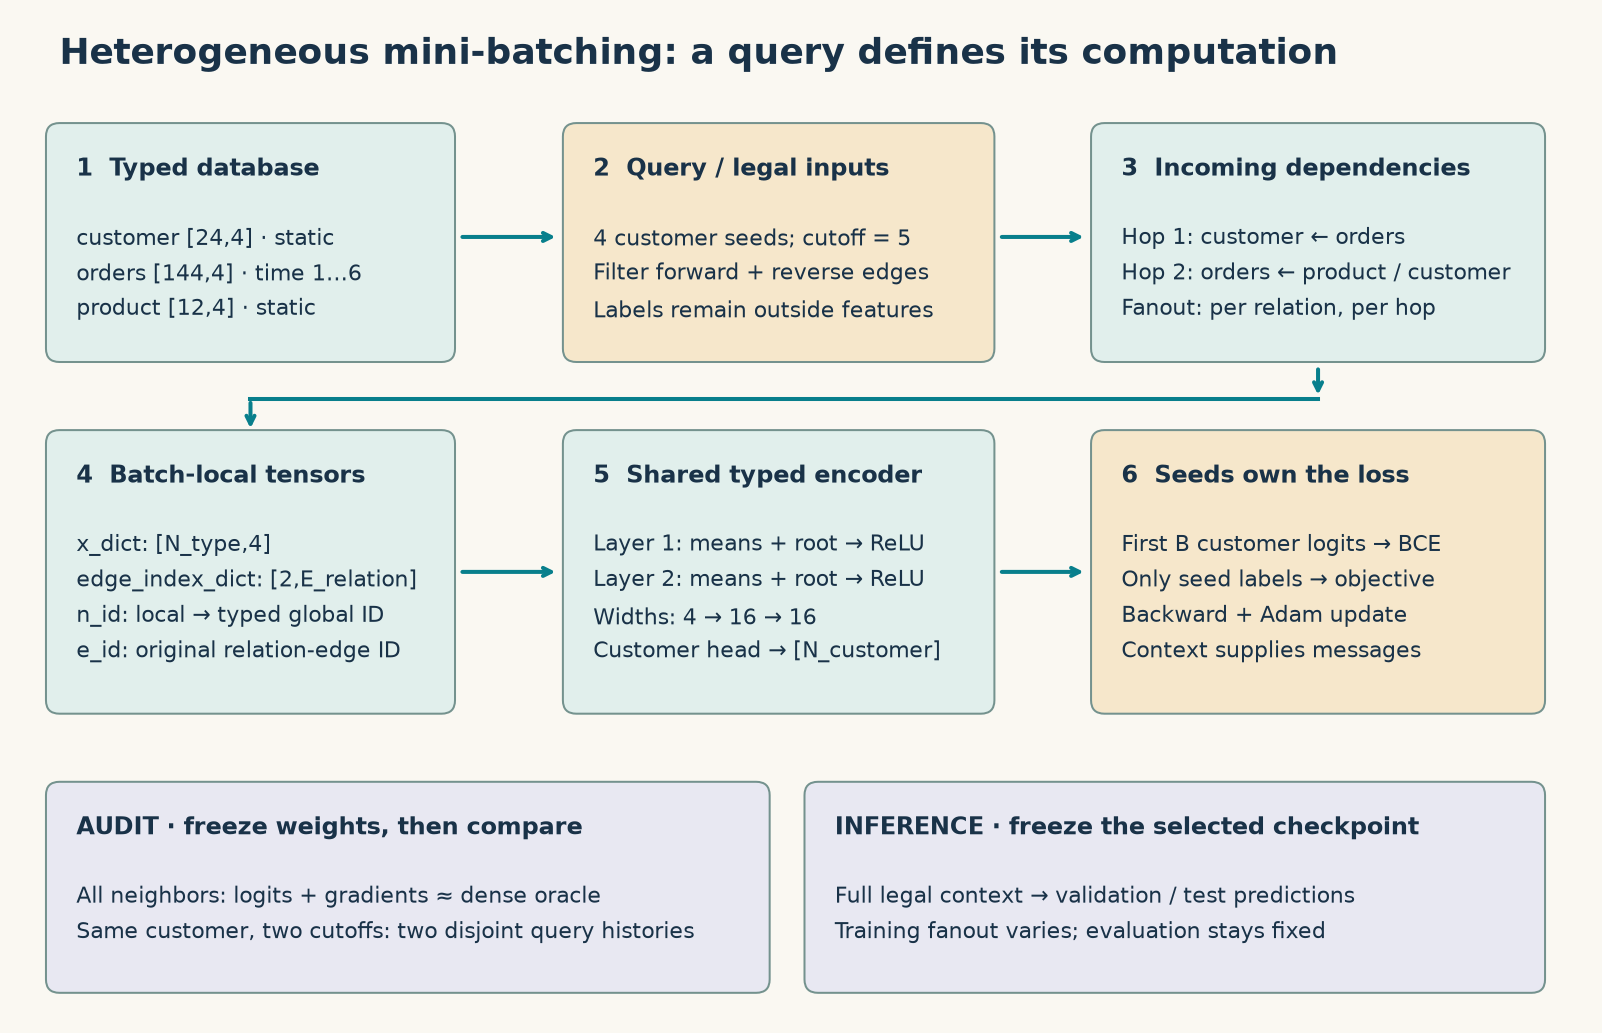</div><figcaption>Sampling expands backward from seed queries; message passing computes forward toward their predictions.</figcaption></figure>

> **In plain terms.** Each destination receives one average message per relationship and keeps a transformed copy of its own features.

For each layer and destination type τ, the visible encoder computes

```text
m_r(v) = mean { h_u : (u, r, v) is present in this batch }
h'_v = ReLU(W_root,τ h_v + b_τ + Σ[r ends at τ] W_r m_r(v))
logit_v = wᵀ h_v^(2) + b, for customer v
```

Here h is a node’s feature vector; W is a learned matrix, b a learned offset, r an edge type and τ a node type. ReLU replaces negative coordinates with zero. A logit is the real-valued score before the sigmoid converts it to a binary probability. BCE is binary cross-entropy: the loss penalizes a confident probability assigned to the wrong label.

An empty relation contributes a zero mean. Each of four edge types has its own message matrix; each of three node types has its own root transform. A root term appears once per destination type, rather than once per relation. Layer widths are 4 → 16 → 16; the customer head returns one logit. The same parameters are reused across batches. This transparent mean encoder is a course model, not an R-GCN or HGT reproduction.

To predict a customer, the first sampling hop follows **incoming** order → customer edges backward to orders. The second reaches products through product → orders and customers through customer → orders. The resulting dependency graph is evaluated in the opposite direction: product features affect order states at layer 1, which affect the customer's layer-2 state. Two sampled hops support two layers. A one-hop loader does not provide the two-hop dependency closure of this model.

At training time, compute BCE on fitting seeds, backpropagate and update parameters. At validation and test time, freeze parameters and use all legal neighbors. The lab retains the checkpoint with lowest validation BCE, then evaluates the four test customers once. This keeps the inference rule fixed across training fanouts.



## 4 · Three IDs that must not be confused

Imagine `batch['orders'].n_id = [42, 44, 43]` and `batch['customer'].n_id = [7]`. A local order → customer edge `(1, 0)` means global order 44 → global customer 7. It does not mean original order 1 → original customer 0. Node IDs are global only **within their type**.

> **Your implementation task:** recover each endpoint through its own type’s `n_id` map, then stack the restored source and destination rows. The CHECK tests unequal local/global IDs so accidental identity mappings cannot pass.

`e_id` identifies the edge in the original relation store, including when the loader internally reorders adjacency. The lab checks recovered endpoints against those edge IDs for every sampled edge. `input_id` instead indexes entries in the input query list; repeated entity IDs at different times can have different input IDs. **Local node index, per-type global node ID and query index are different objects.** [PyG loader API and source](https://pytorch-geometric.readthedocs.io/en/2.6.1/_modules/torch_geometric/loader/neighbor_loader.html).



## 5 · A seed count is a loss boundary, not a node count

```python
loader = NeighborLoader(
    graph,
    input_nodes=('customer', train_ids),
    num_neighbors={edge: [2, 2] for edge in graph.edge_types},
    batch_size=4, shuffle=False, replace=False,
    subgraph_type='directional', num_workers=0,
)
for batch in loader:
    loss = seed_loss(model(batch), batch)  # Your implementation in the lab
```

PyG places the input seeds first in their type's node store. B counts those queries, while the batch also contains context nodes. Our two-hop buyer fixture does not add other customers beyond its seeds; a richer customer graph or deeper sampling can. Always use the seed prefix anyway. The adversarial CHECK gives a context customer an extreme wrong label and verifies that it produces no direct loss gradient.

For an audit that compares accumulated mini-batch gradients with one full-graph **mean** loss, multiply each batch mean by B / total_seeds. Do not take an unweighted average of batch means when the final batch is smaller. Also, do not update parameters between audit batches: multiple optimizer steps are a different optimization trajectory from one full-batch step.

A fanout of 2 is a budget **per destination, per relation, per hop**, not two nodes for the entire graph. Our product and customer reverse relations each supply one predecessor per order. Most approximation therefore comes from sampling only some of the five legal orders per customer. Uniform means without replacement preserve a one-hop mean in expectation, but ReLU and a second layer prevent that observation from proving unbiased final logits or gradients.

**Portable intervention:** run the worked calculation after the implementation.

**Worked route:** products with scalar values 2, 8, −4 send to three separate orders, which send to a customer. Ignore root terms and nonlinearities for this calculation. All three give (2+8−4)/3 = 2; selecting the first two gives 5. The widget uses a deterministic prefix to make arithmetic inspectable. The actual lab uses random uniform native sampling, not prefix sampling.



## 6 · One customer, two prediction times

A training mask says which targets may contribute to a loss; it does not time-filter context. For a single shared cutoff our explicit snapshot is easy to audit. For queries at different times, the lab also executes the real temporal loader:

```python
input_nodes = ('customer', torch.tensor([0, 0]))
input_time = torch.tensor([2, 5])
# Other settings are the same; all neighbors are requested.
loader = NeighborLoader(graph, input_nodes=input_nodes,
    input_time=input_time, time_attr='time', disjoint=True,
    num_neighbors={e: [-1, -1] for e in graph.edge_types},
    batch_size=2, temporal_strategy='uniform')
```

The native temporal result has two customer seed entries with the same `n_id=0` but different `batch` assignments. Event IDs [0,1] belong to the first query and [0,1,2,3,4] to the second. Each copy remains in its query's component. The lab compares the two logits with independently evaluated snapshots at days 2 and 5, checks endpoint component membership, and perturbs future event features by +10,000 without changing the earlier prediction.

The fixture defines availability as time ≤ cutoff and static customer/product timestamps as zero. In a real task, establish whether equality is allowed and whether a supposedly static feature was already available. Sampling does not undo a leaked aggregate, a future-updated product field or a feature normalization fitted on held-out data. Temporal query labels belong to query rows; our temporal audit checks logits only and does not reuse one entity label as ground truth at both times. [Native CPU sampler source](https://github.com/pyg-team/pyg-lib/blob/edc9e2a88d1c5d0953b5f69c98b8365597c6b699/pyg_lib/csrc/sampler/cpu/neighbor_kernel.cpp).



## 7 · Full reproduction of the declared experiment

**Predict first:** with fixed weights and all neighbors, should the seed outputs match a full-graph calculation? Explain before reading the result.

No paper score is assigned to L098. **Full reproduction here means every declared course configuration**, with the actual native sampler, an independent oracle and complete fresh training. It does not establish RelBench benchmark performance.

The correctness track runs 32 generated databases × batch sizes 1, 4 and 24. Every configuration covers all 24 customers exactly once, compares all seed logits with a separately implemented dense adjacency forward, and compares weighted accumulated gradients. Same weights, legal edges, root terms and two-hop depth are held fixed; there is no dropout or batch normalization. Frozen tolerance is 2×10⁻⁶. This establishes full-neighbor computation parity under this contract, not arbitrary sampled-GNN equivalence.

The training track fixes graph seed 98, train/validation/test identities, width 16, 40 epochs, Adam learning rate .02, no weight decay and batch size 4. It runs all neighbors, fanout 2 and fanout 1, each with initialization seeds 0, 1 and 2. Validation BCE chooses the earliest strictly best epoch. Every arm uses full-neighbor validation/test evaluation. Full traces, test logits and the selected model weights are saved. The notebook restores a trained model from JSON arrays and checks its predictions. Batch nodes/edges are workload proxies, not measured peak memory or wall-clock speedups.

**Frozen author results:** 96/96 correctness configurations and 9/9 complete fits. Maximum logit error 8.94e-08; maximum gradient error 5.96e-08. Native temporal isolation passed. Your notebook recomputes everything.

| Training fanout | Mean test accuracy | Mean batch nodes | Mean batch edges | Mean absolute sampled logit gap |
|---|---:|---:|---:|---:|
| all | 0.583 | 34.00 | 60.00 | 0.000000 |
| 2 | 0.583 | 18.22 | 24.00 | 0.413738 |
| 1 | 0.500 | 11.67 | 12.00 | 0.817283 |


**Interpretation:** full neighbors reproduce the seed computation; limited fanout trades context for smaller batches and changes it. Four test examples cannot support a generalization ranking. Three initializations share one graph and are not three independent datasets. The extra logit-gap diagnostic is one sampled evaluation per run, not an expectation estimated over many neighborhoods.

Source hashes, actual package versions, runtime instructions, all deviations and execution records are in the [protocol](https://avistian.github.io/relational/labs/l098-reproduction.md), [source manifest](https://avistian.github.io/relational/labs/_sources_l098.json) and [complete results](https://avistian.github.io/relational/labs/_experiment_l098_results.json). No cached reference is substituted for execution. Colab and deployment are separate delivery states.



## 8 · Implement, falsify, defend

In the student notebook implement **relation_mean**, **seed_loss** and **global_edges**. Each function is called by the real trainer or complete audit; each has an immediate CHECK. The model, graph generator, native loader, dense oracle and training loop are visible in the notebook. Predict a CHECK's answer before running it. Then execute the entire declared experiment from a clean directory.

Submit the fresh JSON result and explain, without looking up the code:

1. Why product → order → customer requires two message-passing layers even though the order FK originally points toward the product.
2. How to recover original typed endpoints from a local edge and why `input_id` is different.
3. Why seed-only loss and a legal-time input graph enforce separate boundaries.
4. Why full-neighbor **gradient accumulation** can match full-batch gradients while sequential SGD updates need not.
5. Which evidence would be missing if someone renamed the nine toy fits “full RelBench reproduction.”

**Teach back:** explain why a seed count differs from a sampled-node count, and why time filtering is a separate boundary.

**Status: PENDING_WRITTEN_DEFENSE.** Prepared material and successful teacher runs are not learner mastery. Tomorrow, reconstruct the two-hop route and seed-loss code from memory. In three days, explain why sampled logits can be biased even when a one-hop mean is unbiased. Ask the agent to quiz you or diagnose any failed CHECK.

Next, curriculum lesson 99 holds the graph and protocol fixed while comparing R-GCN with HGT. Lesson 100 requires you to defend a complete heterogeneous pipeline. Today removes a confound from both: architecture comparisons are only interpretable when batching, target identity and information availability are understood.

**Primary reading:** read the [pinned PyG NeighborLoader source](https://avistian.github.io/relational/labs/sources/l098/neighbor-loader-2.6.1.py) beside the [RelBench entity training example](https://github.com/stanford-star/relbench/blob/584a03d518b2b655580ea8e1cfbbb26bec0a2841/examples/gnn_entity.py). Use the [batching reference sheet](https://avistian.github.io/relational/reference/hetero-batching-contract.html) for review.


## Visible implementation

Read the generated graph and time boundary first. Three functions are your tasks; every other operator and training step is supplied visibly.

In [2]:
import copy

import hashlib

import json

import torch

from torch import nn

from torch.nn import functional as F

from torch_geometric.data import HeteroData

from torch_geometric.loader import NeighborLoader

import torch_geometric.typing as pyg_typing

TYPES=('customer','orders','product')

EDGES=(('orders','buyer','customer'),('customer','rev_buyer','orders'),('orders','item','product'),('product','rev_item','orders'))

CONFIG={'graphs':list(range(32)),'batch_sizes':[1,4,24],'fit_seeds':[0,1,2],'fanouts':[-1,2,1],'epochs':40,'width':16,'lr':0.02,'cutoff':5}

### PROVIDED · make_graph

24 customers, 144 order events (days 1..6), 12 static products; no target features.

In [3]:
def make_graph(seed=0):
    """24 customers, 144 order events (days 1..6), 12 static products; no target features."""
    gen=torch.Generator().manual_seed(seed)
    g=HeteroData()
    for t,n in zip(TYPES,[24,144,12]):
        g[t].x=torch.randn(n,4,generator=gen)
        g[t].time=torch.zeros(n,dtype=torch.long)
    g['orders'].time=torch.arange(1,7).repeat(24)
    customer=torch.arange(24).repeat_interleave(6)
    product=torch.randint(12,(144,),generator=gen)
    order=torch.arange(144)
    for e,ix in [(EDGES[0],torch.stack([order,customer])),(EDGES[2],torch.stack([order,product]))]:
        g[e].edge_index=ix;g[EDGES[EDGES.index(e)+1]].edge_index=ix.flip(0)
    # Synthetic target: sign of average product feature 0 in days <=5.
    # This is deliberately learnable from the graph, not a future-outcome benchmark.
    score=g['product'].x[product,0].reshape(24,6)[:,:5].mean(1)
    g['customer'].y=(score>0).float()
    return g

### PROVIDED · snapshot

Keep stable global row IDs; remove all edges touching unavailable event nodes.

In [4]:
def snapshot(g,cutoff):
    """Keep stable global row IDs; remove all edges touching unavailable event nodes."""
    out=g.clone()
    for src,rel,dst in g.edge_types:
        e=(src,rel,dst);a,b=g[e].edge_index
        keep=(g[src].time[a]<=cutoff)&(g[dst].time[b]<=cutoff)
        out[e].edge_index=g[e].edge_index[:,keep]
    return out

### PROVIDED · make_loader

Two hops for two layers; relation-specific budgets; no replacement or hidden fallback.

In [5]:
def make_loader(g,seeds,fanout=-1,batch_size=4,times=None):
    """Two hops for two layers; relation-specific budgets; no replacement or hidden fallback."""
    if not pyg_typing.WITH_PYG_LIB:
        raise RuntimeError('Install a torch-compatible pyg-lib build; this lab tests real native sampling.')
    options={} if times is None else dict(input_time=torch.as_tensor(times),time_attr='time',disjoint=True,temporal_strategy='uniform')
    return NeighborLoader(g,input_nodes=('customer',torch.as_tensor(seeds,dtype=torch.long)),
        num_neighbors={e:[fanout,fanout] for e in g.edge_types},batch_size=batch_size,
        shuffle=False,replace=False,num_workers=0,subgraph_type='directional',**options)

### TODO · relation_mean

TODO 1: mean incoming source features for each destination, with zero for empty rows.

In [6]:
def relation_mean(x,edge_index,n_dst):
    """TODO 1: mean incoming source features for each destination, with zero for empty rows."""
    src,dst=edge_index
    total=x.new_zeros((n_dst,x.shape[1]));count=x.new_zeros(n_dst)
    total.index_add_(0,dst,x[src]);count.index_add_(0,dst,x.new_ones(dst.numel()))
    return total/count.clamp_min(1).unsqueeze(1)

### CHECK · relation_mean

In [7]:
x=torch.tensor([[2.],[8.],[-4.]],requires_grad=True)
e=torch.tensor([[0,1,2],[0,0,1]])
y=relation_mean(x,e,3)
assert torch.allclose(y,torch.tensor([[5.],[-4.],[0.]]))
y.sum().backward();assert torch.allclose(x.grad,torch.tensor([[.5],[.5],[1.]]))
assert relation_mean(x,torch.empty((2,0),dtype=torch.long),0).shape==(0,1)
print('PASS: independent means, isolates, empty store, gradients')

PASS: independent means, isolates, empty store, gradients


### PROVIDED · TypedMean

Two shared-across-batches typed layers; one root transform plus one per relation.

In [8]:
class TypedMean(nn.Module):
    """Two shared-across-batches typed layers; one root transform plus one per relation."""
    def __init__(self,width=16):
        super().__init__()
        self.roots=nn.ModuleList([nn.ModuleDict({t:nn.Linear(d,width) for t in TYPES}) for d in [4,width]])
        self.messages=nn.ModuleList([nn.ModuleDict({str(i):nn.Linear(d,width,bias=False) for i in range(4)}) for d in [4,width]])
        self.head=nn.Linear(width,1)
    def forward(self,g):
        h=g.x_dict
        for roots,messages in zip(self.roots,self.messages):
            z={t:roots[t](h[t]) for t in TYPES}
            for i,e in enumerate(EDGES):
                src,_,dst=e
                z[dst]=z[dst]+messages[str(i)](relation_mean(h[src],g[e].edge_index,h[dst].shape[0]))
            h={t:F.relu(z[t]) for t in TYPES}
        return self.head(h['customer']).flatten()

### TODO · seed_loss

TODO 2: BCE only for the first B seed customers; context customers are not targets.

In [9]:
def seed_loss(logits,batch):
    """TODO 2: BCE only for the first B seed customers; context customers are not targets."""
    b=batch['customer'].batch_size
    return F.binary_cross_entropy_with_logits(logits[:b],batch['customer'].y[:b])

### CHECK · seed_loss

In [10]:
b=HeteroData();b['customer'].batch_size=2;b['customer'].y=torch.tensor([0.,1.,1.])
z=torch.tensor([0.,0.,100.],requires_grad=True)
loss=seed_loss(z,b);assert abs(loss.item()-0.69314718)<1e-6
loss.backward();assert torch.allclose(z.grad,torch.tensor([.25,-.25,0.]))
b['customer'].y[2]=0.;assert abs(seed_loss(z,b).item()-loss.item())<1e-7
print('PASS: context labels cannot become extra targets')

PASS: context labels cannot become extra targets


### TODO · global_edges

TODO 3: restore per-type global endpoints; never treat local edge IDs as table row IDs.

In [11]:
def global_edges(batch,edge_type):
    """TODO 3: restore per-type global endpoints; never treat local edge IDs as table row IDs."""
    src,_,dst=edge_type;a,b=batch[edge_type].edge_index
    return torch.stack([batch[src].n_id[a],batch[dst].n_id[b]])

### CHECK · global_edges

In [12]:
b=HeteroData();b['orders'].n_id=torch.tensor([42,44,43]);b['customer'].n_id=torch.tensor([7]);b[EDGES[0]].edge_index=torch.tensor([[1,2],[0,0]])
assert global_edges(b,EDGES[0]).tolist()==[[44,43],[7,7]]
print('PASS: local endpoints become typed table row IDs')

PASS: local endpoints become typed table row IDs


### PROVIDED · dense_oracle

Independent dense adjacency forward: no index_add or relation_mean.

In [13]:
def dense_oracle(model,g):
    """Independent dense adjacency forward: no index_add or relation_mean."""
    h=g.x_dict
    for roots,messages in zip(model.roots,model.messages):
        z={t:roots[t](h[t]) for t in TYPES}
        for i,(src,rel,dst) in enumerate(EDGES):
            a,b=g[src,rel,dst].edge_index
            mat=h[src].new_zeros((h[dst].shape[0],h[src].shape[0]))
            for u,v in zip(a.tolist(),b.tolist()):mat[v,u]+=1
            mat=mat/mat.sum(1,keepdim=True).clamp_min(1)
            z[dst]=z[dst]+messages[str(i)](mat@h[src])
        h={t:F.relu(z[t]) for t in TYPES}
    return model.head(h['customer']).flatten()

### PROVIDED · audit_graph

Compare all seed logits and weighted accumulated gradients with a dense full graph.

In [14]:
def audit_graph(seed,batch_size):
    """Compare all seed logits and weighted accumulated gradients with a dense full graph."""
    torch.set_num_threads(1);torch.manual_seed(seed)
    g=snapshot(make_graph(seed),5);model=TypedMean();oracle=copy.deepcopy(model)
    expected=dense_oracle(oracle,g)
    F.binary_cross_entropy_with_logits(expected,g['customer'].y).backward()
    logit_gap=0.;seen=[];batch_nodes=[];batch_edges=[]
    for batch in make_loader(g,range(24),-1,batch_size):
        b=batch['customer'].batch_size;ids=batch['customer'].n_id[:b];seen+=ids.tolist()
        logits=model(batch);logit_gap=max(logit_gap,float((logits[:b]-expected[ids]).abs().max().detach()))
        (seed_loss(logits,batch)*b/24).backward()
        batch_nodes.append(sum(batch[t].num_nodes for t in TYPES))
        batch_edges.append(sum(batch[e].num_edges for e in EDGES))
        for e in EDGES:
            restored=global_edges(batch,e)
            # e_id indexes the original unsorted edge store, despite internal CSC sorting.
            assert torch.equal(restored,g[e].edge_index[:,batch[e].e_id])
            assert set(map(tuple,restored.t().tolist()))<=set(map(tuple,g[e].edge_index.t().tolist()))
    assert all((a.grad is None)==(b.grad is None) for a,b in zip(model.parameters(),oracle.parameters()))
    gap=max(float((a.grad-b.grad).abs().max()) for a,b in zip(model.parameters(),oracle.parameters()) if a.grad is not None)
    assert sorted(seen)==list(range(24)) and len(set(seen))==24
    return dict(graph_seed=seed,batch_size=batch_size,max_logit_gap=logit_gap,max_gradient_gap=gap,seed_coverage=seen,max_batch_nodes=max(batch_nodes),max_batch_edges=max(batch_edges))

### PROVIDED · temporal_audit

Two queries for customer 0 at days 2 and 5; compare to separate filtered snapshots.

In [15]:
def temporal_audit():
    """Two queries for customer 0 at days 2 and 5; compare to separate filtered snapshots."""
    torch.manual_seed(98);g=make_graph(3);model=TypedMean()
    batch=next(iter(make_loader(g,[0,0],-1,2,[2,5])))
    assert batch['customer'].n_id[:2].tolist()==[0,0]
    assert batch['customer'].batch[:2].tolist()==[0,1]
    expected=torch.stack([dense_oracle(model,snapshot(g,t))[0] for t in [2,5]])
    gap=float((model(batch)[:2]-expected).abs().max().detach());assert gap<2e-6
    for t in TYPES:
        assert (g[t].time[batch[t].n_id]<=torch.tensor([2,5])[batch[t].batch]).all()
    for e in EDGES:
        a,b=batch[e].edge_index
        assert torch.equal(batch[e[0]].batch[a],batch[e[2]].batch[b])
    # Future changes cannot affect an earlier seed. This includes static product hazards:
    # only future event features are changed here; static products must themselves be available.
    changed=g.clone();changed['orders'].x[changed['orders'].time>2]+=10000
    early=next(iter(make_loader(changed,[0],-1,1,[2])))
    assert torch.allclose(model(early)[0],expected[0],atol=2e-6)
    return {'status':'PASS','query_ids':[0,0],'cutoffs':[2,5],'max_logit_gap':gap,'event_ids':{str(k):batch['orders'].n_id[batch['orders'].batch==k].tolist() for k in [0,1]}}

### PROVIDED · train

Fixed graph/splits/budget; validation chooses checkpoint; test evaluated once afterward.

In [16]:
def train(seed,fanout):
    """Fixed graph/splits/budget; validation chooses checkpoint; test evaluated once afterward."""
    torch.manual_seed(seed);g=snapshot(make_graph(98),5);model=TypedMean()
    opt=torch.optim.Adam(model.parameters(),lr=CONFIG['lr']);best=float('inf');state=None;history=[]
    for epoch in range(CONFIG['epochs']):
        model.train();total=0.
        for batch in make_loader(g,range(16),fanout,4):
            opt.zero_grad();loss=seed_loss(model(batch),batch);loss.backward();opt.step();total+=float(loss.detach())/4
        model.eval()
        with torch.no_grad():v=F.binary_cross_entropy_with_logits(model(g)[16:20],g['customer'].y[16:20]).item()
        history.append({'epoch':epoch+1,'train_bce':total,'val_bce':v})
        if v<best:best=v;state=copy.deepcopy(model.state_dict());chosen=epoch+1
    model.load_state_dict(state);model.eval()
    with torch.no_grad():
        all_logits=model(g);test=all_logits[20:];labels=g['customer'].y[20:]
        loss=F.binary_cross_entropy_with_logits(test,labels).item();acc=((test>=0)==labels.bool()).float().mean().item()
        gaps=[];nodes=[];edges=[]
        for batch in make_loader(g,range(24),fanout,4):
            b=batch['customer'].batch_size;ids=batch['customer'].n_id[:b]
            gaps.extend((model(batch)[:b]-all_logits[ids]).abs().tolist())
            nodes.append(sum(batch[t].num_nodes for t in TYPES));edges.append(sum(batch[e].num_edges for e in EDGES))
    return {'seed':seed,'fanout':fanout,'selected_epoch':chosen,'val_bce':best,'test_bce':loss,'test_accuracy':acc,'mean_abs_sampled_logit_gap':sum(gaps)/len(gaps),'mean_batch_nodes':sum(nodes)/len(nodes),'mean_batch_edges':sum(edges)/len(edges),'test_logits':test.tolist(),'test_labels':labels.tolist(),'history':history,'state_dict':{k:v.tolist() for k,v in model.state_dict().items()}}

### PROVIDED · restore_model

Restore the selected trained model from transparent JSON arrays for fresh inference.

In [17]:
def restore_model(run):
    """Restore the selected trained model from transparent JSON arrays for fresh inference."""
    model=TypedMean(CONFIG['width'])
    model.load_state_dict({k:torch.tensor(v,dtype=model.state_dict()[k].dtype) for k,v in run['state_dict'].items()})
    return model.eval()

### PROVIDED · run_suite

All 96 correctness configurations, native temporal test, nine complete training fits.

In [18]:
def run_suite():
    """All 96 correctness configurations, native temporal test, nine complete training fits."""
    torch.set_num_threads(1)
    records=[audit_graph(s,b) for s in CONFIG['graphs'] for b in CONFIG['batch_sizes']]
    assert max(r['max_logit_gap'] for r in records)<2e-6
    assert max(r['max_gradient_gap'] for r in records)<2e-6
    temporal=temporal_audit();runs=[train(s,f) for f in CONFIG['fanouts'] for s in CONFIG['fit_seeds']]
    for run in runs:
        with torch.no_grad(): replay=restore_model(run)(snapshot(make_graph(98),5))[20:]
        assert torch.allclose(replay,torch.tensor(run['test_logits']),atol=1e-7)
    return {'status':'PASS','config':CONFIG,'audit':records,'temporal':temporal,'runs':runs,'scope':'Complete synthetic course experiment; no RelBench benchmark or paper score reproduction','paper_parity':'NOT_ESTABLISHED','relbench_benchmark':'NOT_RUN'}

## Predict → intervene → explain

For values [2,8,-4], predict the full mean and prefix-two mean. Then inspect actual IDs, component membership and per-type counts from the native loader.

In [19]:
values=torch.tensor([2.,8.,-4.])
assert values.mean()==2 and values[:2].mean()==5
g=snapshot(make_graph(98),5)
b=next(iter(make_loader(g,[7],-1,1)))
print({t:b[t].n_id.tolist() for t in TYPES})
print('seed count',b['customer'].batch_size)
print(temporal_audit())

{'customer': [7], 'orders': [43, 44, 45, 46, 42], 'product': [2, 10, 6, 1]}
seed count 1


{'status': 'PASS', 'query_ids': [0, 0], 'cutoffs': [2, 5], 'max_logit_gap': 0.0, 'event_ids': {'0': [0, 1], '1': [0, 1, 2, 3, 4]}}


## Full fresh reproduction

Runs all 96 correctness configurations and nine 40-epoch fits. Compare fresh full-neighbor invariants before comparing stochastic optimization traces. Frozen author metrics below are explicitly references, never replacements for fresh computation.

In [20]:
fresh=run_suite()
from pathlib import Path
Path('l098-fresh.json').write_text(json.dumps(fresh,indent=2)+'\n')
assert len(fresh['audit'])==96 and len(fresh['runs'])==9
trained=restore_model(fresh['runs'][0])
with torch.no_grad(): print('Restored trained model test logits:', trained(snapshot(make_graph(98),5))[20:])
AUTHOR_TEST_BCE=[0.6869847774505615, 0.5015562176704407, 0.730786144733429, 0.695512056350708, 0.5836430788040161, 0.735620379447937, 0.700424075126648, 0.8304041028022766, 0.728486955165863]
print('BCE gaps from frozen author runs:',[abs(r['test_bce']-a) for r,a in zip(fresh['runs'],AUTHOR_TEST_BCE)])
print('Full course suite:',fresh['status'], '; RelBench benchmark:',fresh['relbench_benchmark'])
print([(r['seed'],r['fanout'],r['selected_epoch'],r['test_accuracy']) for r in fresh['runs']])

Restored trained model test logits: tensor([-0.8915, -0.3560, -0.5667, -0.4295])
BCE gaps from frozen author runs: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Full course suite: PASS ; RelBench benchmark: NOT_RUN
[(0, -1, 1, 0.5), (1, -1, 8, 0.75), (2, -1, 1, 0.5), (0, 2, 1, 0.5), (1, 2, 7, 0.75), (2, 2, 1, 0.5), (0, 1, 1, 0.5), (1, 1, 16, 0.5), (2, 1, 1, 0.5)]


## EXIT · PENDING_WRITTEN_DEFENSE

Submit your three implementations, l098-fresh.json and the five written defenses in section 8. Explain the time boundary, typed ID reconstruction, seed-only loss, weighting of accumulated gradients and remaining RelBench reproduction gaps. Ask the agent to challenge your explanation.